In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [49]:
print('PROJECT:- Fitness Tracker')

PROJECT:- Fitness Tracker


In [50]:
class FitnessTracker:
    def __init__ (self):
        self.data = pd.DataFrame(columns=['date','activity_type','duration','calories'])

    def log_activity(self,activity_type,duration,calories):
        Data={
            'date' : datetime.now().strftime('%y-%m-%d'),
            'activity_type' : activity_type,
            'duration' : duration,
            'calories' : calories
        }

        self.data = pd.concat([self.data,pd.DataFrame([Data])],ignore_index = True)
        print('Successful Data inserted')

    def calculate_metric(self):
        activity_freq = self.data['activity_type'].value_counts()
        avg_duration = self.data['duration'].mean()
        cal_burned = self.data['calories'].sum()

        metrics = {
            'Activities Frequency' : activity_freq,
            'Average duration' : avg_duration,
            'Calories burned' : cal_burned
        }
        return metrics

    def filter_activities(self, activity_type, start_date, end_date):
        filterdata = self.data.copy()

        if activity_type:
            filterdata = filterdata[filterdata["activity_type"] == activity_type]

        if start_date:
            filterdata = filterdata[filterdata["date"] == start_date]

        if end_date:
            filterdata = filterdata[filterdata["date"] == end_date]

            return filterdata

    def generate_report(self):
        print('FITNESS DATA REPORTS')
        print(self.data)
        print(self.calculate_metric())

tracker =FitnessTracker()

In [51]:
tracker.log_activity('skipping', 30, 300)
tracker.log_activity('running', 10, 100)
tracker.log_activity('yoga', 50, 250)
print(tracker.data)

Successful Data inserted
Successful Data inserted
Successful Data inserted
       date activity_type duration calories
0  25-12-29      skipping       30      300
1  25-12-29       running       10      100
2  25-12-29          yoga       50      250


In [52]:
print('Calculate Metric')
tracker.calculate_metric()

Calculate Metric


{'Activities Frequency': activity_type
 skipping    1
 running     1
 yoga        1
 Name: count, dtype: int64,
 'Average duration': np.float64(30.0),
 'Calories burned': 650}

In [54]:
print('Filtering Activities')
tracker.filter_activities('yoga', '25-12-29', '25-12-29')

Filtering Activities


,date,activity_type,duration,calories
2,25-12-29,yoga,50,250


In [55]:
print('Generate Reports of Activities')
tracker.generate_report()

Generate Reports of Activities
FITNESS DATA REPORTS
       date activity_type duration calories
0  25-12-29      skipping       30      300
1  25-12-29       running       10      100
2  25-12-29          yoga       50      250
{'Activities Frequency': activity_type
skipping    1
running     1
yoga        1
Name: count, dtype: int64, 'Average duration': np.float64(30.0), 'Calories burned': 650}


- Load the dataset and display

In [56]:
data = pd.read_csv(r'C:\Users\ASUS\Documents\archive\fitness_activities.csv')
print(data)

           Date Activity Type  Duration (Minutes)  Calories Burned  \
0    2024-01-01       Walking                 114             1026   
1    2024-01-02       Walking                  70              490   
2    2024-01-03          HIIT                  30              360   
3    2024-01-04          HIIT                  60              420   
4    2024-01-05          Yoga                  52              520   
..          ...           ...                 ...              ...   
595  2025-08-18       Running                  26              182   
596  2025-08-19      Swimming                  92              920   
597  2025-08-20      Swimming                 113             1356   
598  2025-08-21       Cycling                 102              714   
599  2025-08-22          HIIT                  31              155   

    Intensity Level  Steps  Distance (km)  Average Heart Rate  
0            Medium   7927           7.96                 103  
1               Low   8909     

In [57]:

pd.read_csv(r'C:\Users\ASUS\Documents\archive\fitness_activities.csv')

,Date,Activity Type,Duration (Minutes),Calories Burned,Intensity Level,Steps,Distance (km),Average Heart Rate
0,2024-01-01,Walking,114,1026,Medium,7927,7.96,103
1,2024-01-02,Walking,70,490,Low,8909,14.91,105
2,2024-01-03,HIIT,30,360,Low,12807,10.84,138
3,2024-01-04,HIIT,60,420,Medium,12227,11.68,153
4,2024-01-05,Yoga,52,520,High,2729,8.77,91
...,...,...,...,...,...,...,...,...
595,2025-08-18,Running,26,182,High,6448,5.21,113
596,2025-08-19,Swimming,92,920,High,7789,6.00,108
597,2025-08-20,Swimming,113,1356,Low,9718,12.75,127
598,2025-08-21,Cycling,102,714,High,11169,2.31,139


- Display dataset Info

In [58]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                600 non-null    object 
 1   Activity Type       600 non-null    object 
 2   Duration (Minutes)  600 non-null    int64  
 3   Calories Burned     600 non-null    int64  
 4   Intensity Level     600 non-null    object 
 5   Steps               600 non-null    int64  
 6   Distance (km)       600 non-null    float64
 7   Average Heart Rate  600 non-null    int64  
dtypes: float64(1), int64(4), object(3)
memory usage: 37.6+ KB


- Check Null values in Dataset

In [59]:
print('Null Values in datasheet')
data.isnull().sum()

Null Values in datasheet


Date                  0
Activity Type         0
Duration (Minutes)    0
Calories Burned       0
Intensity Level       0
Steps                 0
Distance (km)         0
Average Heart Rate    0
dtype: int64

- Check Duplicate values in Dataset

In [60]:
print('Duplicate items :' ,data.duplicated().sum())

Duplicate items : 0


- Removing columns that are not important & load new dataset

In [61]:
new_data = data.drop(columns= ['Steps','Distance (km)','Average Heart Rate'])
new_data

,Date,Activity Type,Duration (Minutes),Calories Burned,Intensity Level
0,2024-01-01,Walking,114,1026,Medium
1,2024-01-02,Walking,70,490,Low
2,2024-01-03,HIIT,30,360,Low
3,2024-01-04,HIIT,60,420,Medium
4,2024-01-05,Yoga,52,520,High
...,...,...,...,...,...
595,2025-08-18,Running,26,182,High
596,2025-08-19,Swimming,92,920,High
597,2025-08-20,Swimming,113,1356,Low
598,2025-08-21,Cycling,102,714,High


In [62]:
new_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Date                600 non-null    object
 1   Activity Type       600 non-null    object
 2   Duration (Minutes)  600 non-null    int64 
 3   Calories Burned     600 non-null    int64 
 4   Intensity Level     600 non-null    object
dtypes: int64(2), object(3)
memory usage: 23.6+ KB


- Convert dtype of Date , object to datetime

In [63]:
new_data['Date'] = pd.to_datetime(new_data['Date'])
new_data.dtypes

Date                  datetime64[ns]
Activity Type                 object
Duration (Minutes)             int64
Calories Burned                int64
Intensity Level               object
dtype: object

- Aggregate

In [64]:
max_duration = np.max(new_data['Duration (Minutes)'])
min_duration = np.min(new_data['Duration (Minutes)'])
avg_duration = np.mean(new_data['Duration (Minutes)'])

In [65]:
print('Maximum Duration :', max_duration,'min')
print('Minimum Duration :', min_duration,'min')
print('Average Duration :', round(avg_duration,2),'min')

Maximum Duration : 120 min
Minimum Duration : 20 min
Average Duration : 71.55 min


- Groupby Activity Type by Duration, calories

In [66]:
time_act = new_data.groupby('Activity Type')['Duration (Minutes)'].sum()
cal_act = new_data.groupby('Activity Type')['Calories Burned'].sum()

In [67]:
print('Total Duration by Activities :', time_act)
print('=='*50)
print('Total Calories burned in Activities :', cal_act)

Total Duration by Activities : Activity Type
Cycling     7272
Gym         6637
HIIT        5726
Running     5411
Swimming    5193
Walking     6028
Yoga        6665
Name: Duration (Minutes), dtype: int64
Total Calories burned in Activities : Activity Type
Cycling     61176
Gym         55723
HIIT        46814
Running     48892
Swimming    45071
Walking     49963
Yoga        59439
Name: Calories Burned, dtype: int64


- Visualizing

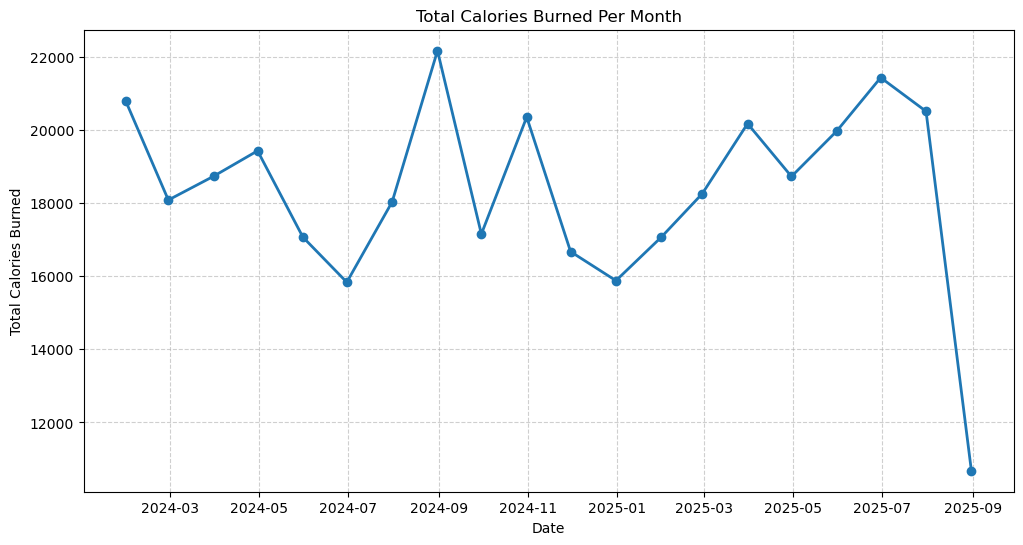

In [68]:
daily_calories = (new_data.set_index('Date')['Calories Burned'].resample('ME').sum())

plt.figure(figsize=(12, 6))
plt.plot(daily_calories.index,daily_calories.values,marker='o',linestyle='-',linewidth=2)

plt.title('Total Calories Burned Per Month')
plt.xlabel('Date')
plt.ylabel('Total Calories Burned')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

- How steady your daily calorie burn is across weeks/months.
- In 2024/09 burn the higher amount calories, but in 2025/09 amount of burning the calories are dump from 22000 approx to 9000 approx.

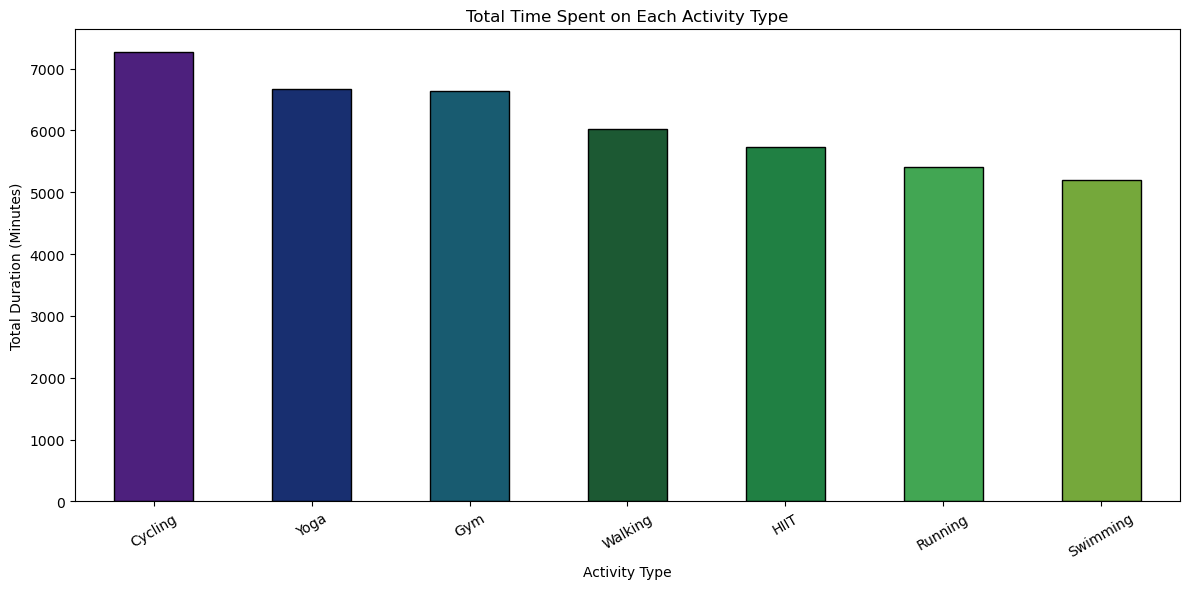

In [83]:
time_spend = new_data.groupby('Activity Type')['Duration (Minutes)'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
time_spend.plot(kind='bar', color=['#4D207D','#182F70','#185B70','#1C5933','#208043','#42A653','#75A83B'],edgecolor='black')

plt.title("Total Time Spent on Each Activity Type")
plt.xlabel("Activity Type")
plt.ylabel("Total Duration (Minutes)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

- Total Time Spent on Each Activity Type
- Most time spend on cycling 7000+ min. and therefore meanwhile swimming as lowest time spend less than 6000 min.

- Pie chart

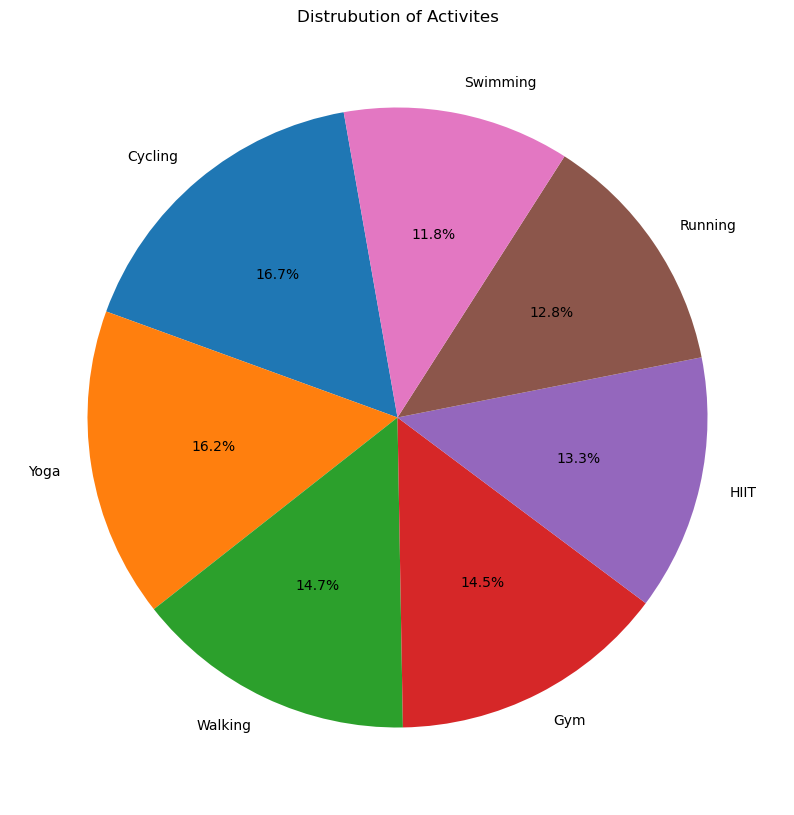

In [84]:
count = new_data['Activity Type'].value_counts()

plt.figure(figsize=(10,15))
plt.pie(count, labels=count.index, autopct='%1.1f%%',startangle=100)

plt.title('Distrubution of Activites')
plt.show()

- distribution and timing of different physical activities

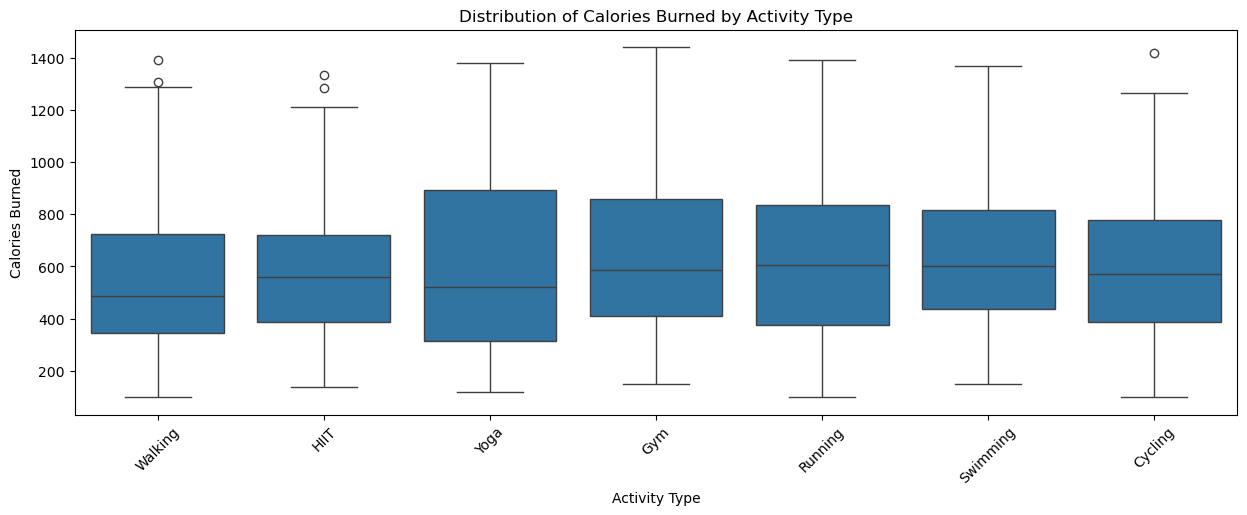

In [96]:
plt.figure(figsize=(15,5))
sns.boxplot(x='Activity Type', y='Calories Burned', data=new_data)
plt.title('Distribution of Calories Burned by Activity Type')
plt.xticks(rotation=45)
plt.show()

- Instead of showing every single workout session, a box plot summarizes where most of your activities fell on the calendar. Here is how to read each part of the boxes.

- Heatmap

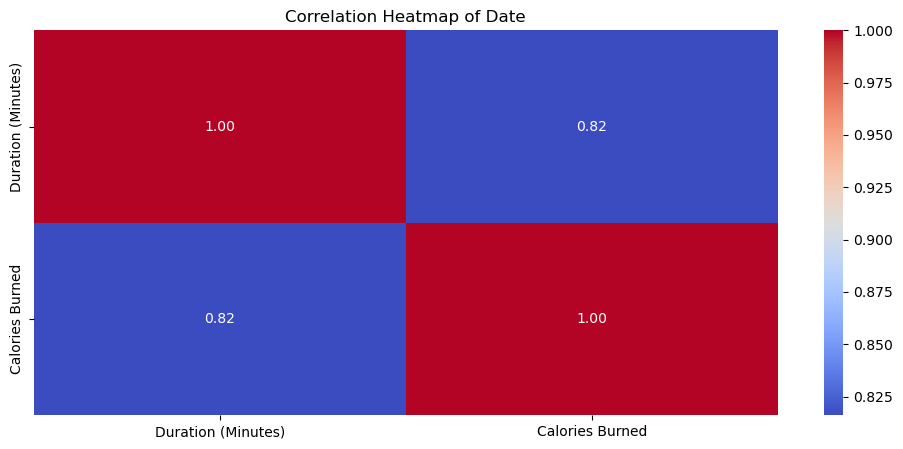

In [97]:
plt.figure(figsize=(12,5))

date = new_data.select_dtypes(include=['number'])
correlation_matrix = date.corr()

sns.heatmap(correlation_matrix, annot= True, cmap= 'coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Date')
plt.show()

In [98]:
new_data.to_csv('fitness_activities.csv', index=False)